In [47]:
import pickle
import pandas as pd
import joblib
import matplotlib.pyplot as plt

In [10]:
new_data = pd.read_csv('new_data_with_headings.csv')
new_data.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,66,28,120000,MORTGAGE,13,VENTURE,C,7200,14.72,0.06,Y,6
1,67,26,30000,RENT,2,MEDICAL,A,12000,7.51,0.40,N,4
2,68,31,62900,MORTGAGE,2,MEDICAL,D,18000,14.09,0.24,N,5
3,69,24,40000,RENT,3,MEDICAL,C,3000,13.22,0.07,N,4
4,70,43,68000,MORTGAGE,0,MEDICAL,A,5000,8.90,0.07,N,17


In [31]:
model = joblib.load('random_forest_model.pkl')


encoder = joblib.load('onehot_encoder.pkl')

with open('model_columns.pkl' , 'rb') as f:
    extra_columns = pickle.load(f)
    extra_columns = pd.DataFrame(columns = extra_columns)

headings = joblib.load('headings.pkl')
    

In [32]:
cat_cols = ['person_home_ownership' , 'loan_intent' , 'loan_grade' , 'cb_person_default_on_file']
encoded_cat = encoder.fit_transform(new_data[cat_cols])

encoded_df = pd.DataFrame(encoded_cat, columns= encoder.get_feature_names_out(cat_cols))


df_encoded = pd.concat([new_data.drop(columns= cat_cols), encoded_df], axis = 1)

for col in extra_columns:
    if col not in df_encoded.columns:
        df_encoded[col] = 0

df_encoded = df_encoded[headings]

In [33]:
predictions = model.predict(df_encoded)

print(predictions)

[0 1 1 0 0 0 0 0 0 0]


In [44]:
importances = model.feature_importances_
headings = model.feature_names_in_

table = pd.DataFrame({
    "Feature": headings ,
    "Importance": importances})

In [ ]:
table = table.sort_values(['Importance'], ascending=False)
table


,Feature,Importance
6,loan_percent_income,0.224797
5,loan_int_rate,0.132788
2,person_income,0.105913
18,loan_grade_D,0.079641
10,person_home_ownership_RENT,0.071561
4,loan_amnt,0.069465
0,id,0.062387
3,person_emp_length,0.053065
1,person_age,0.041808
7,cb_person_cred_hist_length,0.032535


<BarContainer object of 23 artists>

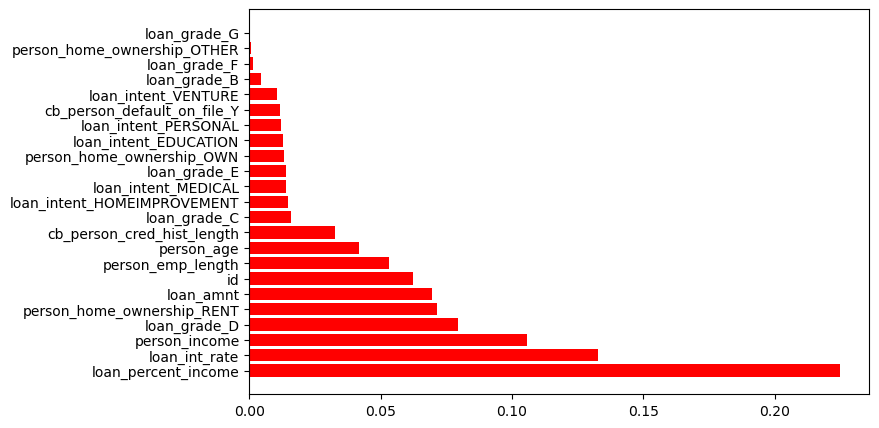

In [50]:
plt.figure(figsize=(8, 5))
plt.barh(table["Feature"], table["Importance"] , color = "red")

In [57]:
headings

array(['id', 'person_age', 'person_income', 'person_emp_length',
       'loan_amnt', 'loan_int_rate', 'loan_percent_income',
       'cb_person_cred_hist_length', 'person_home_ownership_OTHER',
       'person_home_ownership_OWN', 'person_home_ownership_RENT',
       'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT',
       'loan_intent_MEDICAL', 'loan_intent_PERSONAL',
       'loan_intent_VENTURE', 'loan_grade_B', 'loan_grade_C',
       'loan_grade_D', 'loan_grade_E', 'loan_grade_F', 'loan_grade_G',
       'cb_person_default_on_file_Y'], dtype=object)